# Decision Tree Implementation using CART Algorithm
## Data Analytics and Visualization Assignment



---

## 1. Import  Libraries

In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn for comparison and datasets
from sklearn.datasets import load_iris, load_wine, make_classification, make_regression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Our custom implementations
from decision_tree_cart import DecisionTreeCART, Node
from tree_visualizer import TreeVisualizer, plot_decision_boundary_2d
from example_datasets import DatasetExamples, split_and_describe_data
from evaluation_metrics import TreeEvaluator, ClassificationEvaluator, RegressionEvaluator

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("All libraries imported successfully!")
print("CART Decision Tree implementation ready for demonstration.")

All libraries imported successfully!
CART Decision Tree implementation ready for demonstration.


## 2. Prepare Dataset

We'll use the classic **Iris Dataset** for our CART implementation demonstration:

### Iris Dataset:
- **Purpose**: Classic flower classification problem
- **Classes**: 3 iris species (Setosa, Versicolor, Virginica)
- **Features**: 4 measurements (sepal length, sepal width, petal length, petal width)
- **Samples**: 150 total (50 per species)
- **Why chosen**: Perfect for demonstrating decision tree concepts with clear feature relationships

In [ ]:
# Load the Iris dataset
print("Loading Dataset...")
print("="*30)

# Iris Dataset - our primary dataset for demonstration
X_iris, y_iris, iris_info = DatasetExamples.load_dataset('iris')
print(f"✓ Iris Dataset: {X_iris.shape[0]} samples, {X_iris.shape[1]} features")
print(f"  • Classes: {sorted(y_iris.unique())}")
print(f"  • Features: {list(X_iris.columns)}")

print("\n🎯 Dataset loaded successfully!")
print("Ready to demonstrate CART algorithm on iris flower classification!")

Loading Classification Datasets...
✓ Iris Dataset: 150 samples, 4 features
✓ Wine Dataset: 178 samples, 13 features
✓ Titanic-like Dataset: 800 samples, 6 features

Loading Regression Datasets...
✓ Housing Dataset: 1000 samples, 7 features
✓ Synthetic Regression Dataset: 500 samples, 4 features

🎯 All datasets loaded successfully!


## 3. Explore the Iris Dataset

Let's perform exploratory data analysis to understand our dataset better:

In [ ]:
# Explore Iris Dataset
print("IRIS DATASET EXPLORATION")
print("="*40)

# Basic info
print(f"Shape: {X_iris.shape}")
print(f"Features: {list(X_iris.columns)}")
print(f"Target classes: {sorted(y_iris.unique())}")
print(f"Class distribution:")
print(y_iris.value_counts().sort_index())

# Visualize Iris dataset
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Iris Dataset Exploration', fontsize=16, fontweight='bold')

# Pairwise scatter plots
for i, feature in enumerate(X_iris.columns[:4]):
    ax = axes[i//2, i%2]
    for species in sorted(y_iris.unique()):
        mask = y_iris == species
        ax.scatter(X_iris.loc[mask, feature], np.random.normal(0, 0.02, sum(mask)), 
                  label=f'Species {species}', alpha=0.7, s=50)
    ax.set_xlabel(feature)
    ax.set_title(f'Distribution of {feature}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation matrix
plt.figure(figsize=(8, 6))
correlation_matrix = X_iris.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f')
plt.title('Feature Correlation Matrix - Iris Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. CART Algorithm Theory

The CART (Classification and Regression Trees) algorithm works by recursively splitting the data based on feature values to create a decision tree. Key mathematical concepts:

- **Gini Impurity (Classification)**: $Gini = 1 - \sum_{i=1}^{c} p_i^2$
- **Information Gain**: Measures how much a split reduces impurity
- **Best Split Selection**: Choose feature and threshold that maximizes information gain
- **Stopping Criteria**: Based on depth, sample size, or impurity thresholds

## 5. Train CART Classifier on Iris Dataset

In [4]:
# Train CART Classifier on Iris Dataset
print("🌸 CLASSIFICATION EXAMPLE: IRIS DATASET")
print("="*50)

# Split the data
X_train_iris, X_test_iris, y_train_iris, y_test_iris = split_and_describe_data(
    X_iris, y_iris, test_size=0.3, random_state=42
)

print("\n" + "="*50)

# Create and train our CART classifier
cart_classifier = DecisionTreeCART(
    task_type='classification',
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

print("Training CART Classifier...")
cart_classifier.fit(X_train_iris, y_train_iris)

# Make predictions
y_pred_iris = cart_classifier.predict(X_test_iris)

print("✅ Training completed!")
print(f"Tree Depth: {cart_classifier.get_depth()}")
print(f"Number of Leaves: {cart_classifier.get_n_leaves()}")

# Display first few predictions
print(f"\nFirst 10 predictions:")
print(f"True:      {list(y_test_iris.iloc[:10])}")
print(f"Predicted: {list(y_pred_iris[:10])}")

# Calculate accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test_iris, y_pred_iris)
print(f"\nTest Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

🌸 CLASSIFICATION EXAMPLE: IRIS DATASET
Dataset Information:
Total samples: 150
Features: 4
Training samples: 105
Test samples: 45
\nTarget distribution:
species
0    50
1    50
2    50
Name: count, dtype: int64
\nFeature statistics (training set):
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         105.000000        105.000000         105.000000   
mean            5.873333          3.055238           3.784762   
std             0.862941          0.457203           1.784052   
min             4.300000          2.000000           1.100000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.200000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        105.000000  
mean           1.205714  
std            0.777549  
min            0.100000  
25%            0.300000  
50%       

## 6. Visualize the Decision Tree

Let's create comprehensive visualizations of our trained CART model:

🌳 DECISION TREE VISUALIZATION
Plotting tree structure...


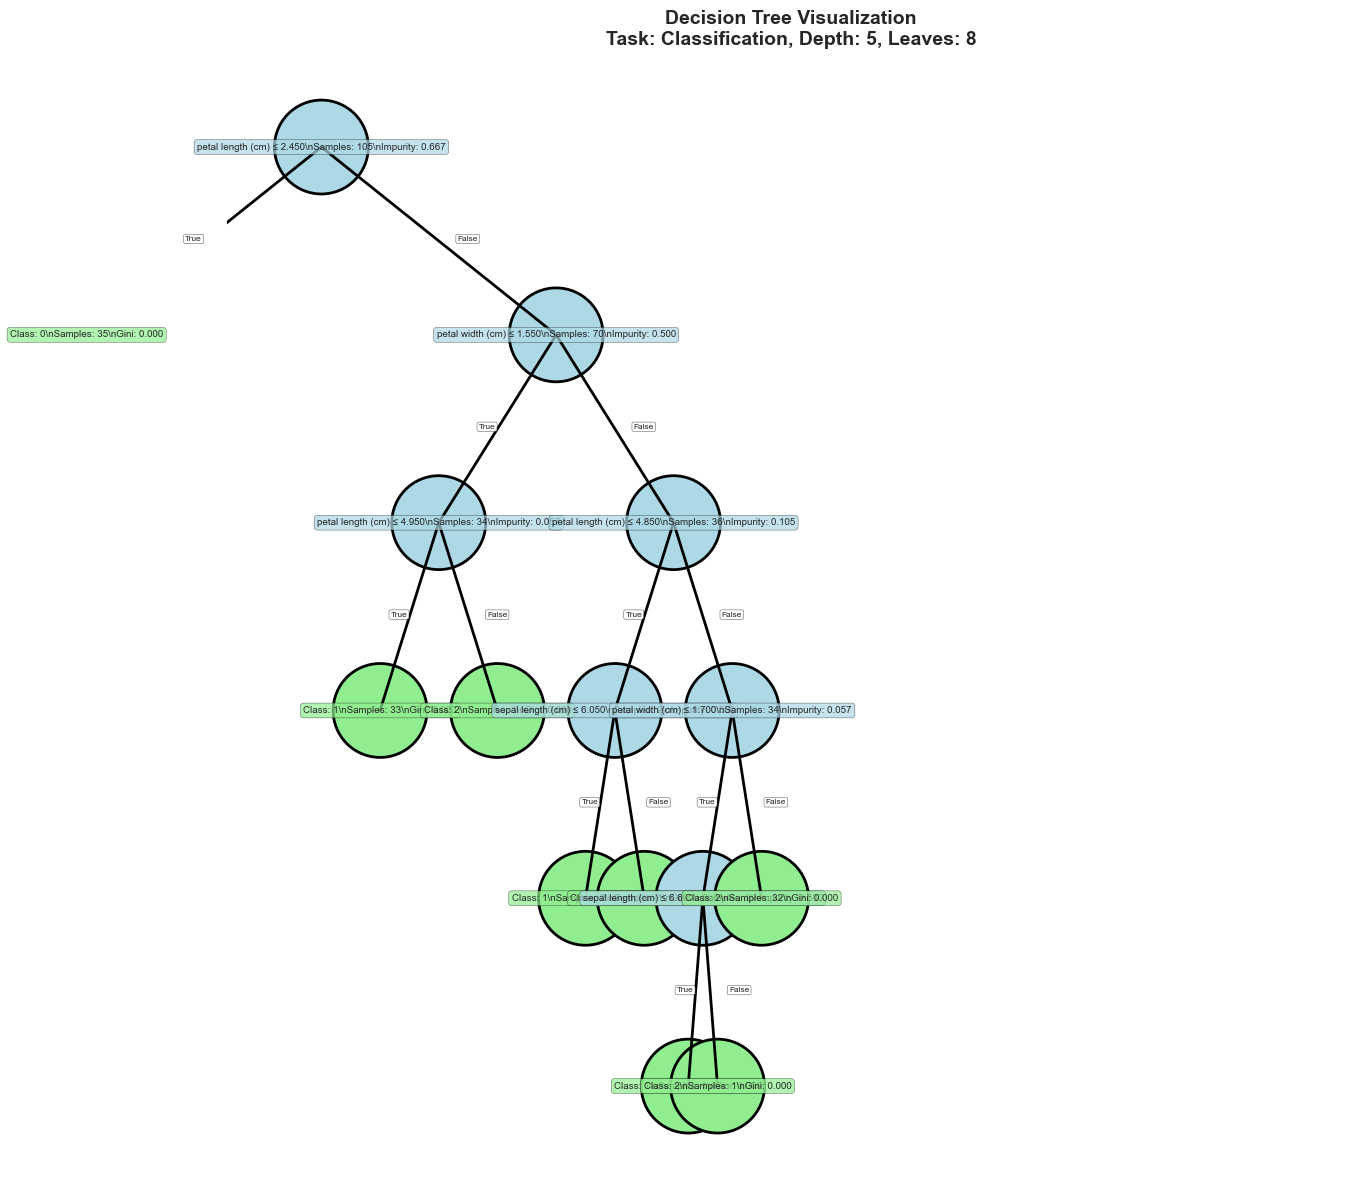

Plotting feature importance...


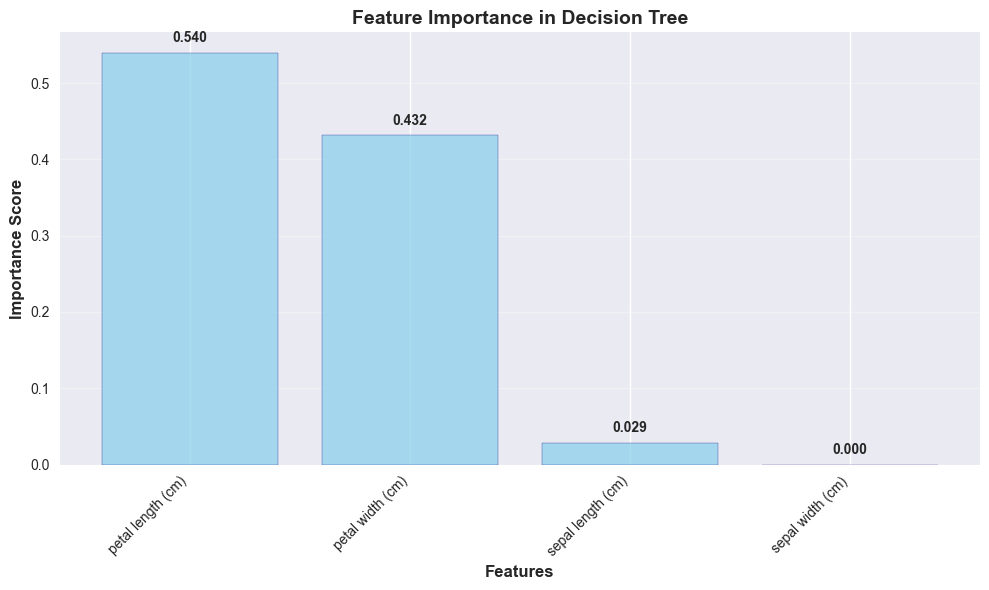


✅ Tree visualization completed!


In [6]:
# Visualize Decision Tree Structure
print("🌳 DECISION TREE VISUALIZATION")
print("="*35)

# Create visualizer for the tree
tree_viz = TreeVisualizer(cart_classifier)

# Plot tree structure
print("Plotting tree structure...")
tree_viz.plot_tree(figsize=(16, 12), node_size=2000, font_size=9)

# Plot feature importance
print("Plotting feature importance...")
tree_viz.plot_feature_importance(figsize=(10, 6))



print("\n✅ Tree visualization completed!")

In [ ]:
# Visualize Decision Boundary (2D projection)
print("\n🎯 DECISION BOUNDARY VISUALIZATION") 
print("="*40)

# Create 2D visualization using first two features
X_2d = X_train_iris.iloc[:, [0, 1]].values  # Sepal length and width
y_2d = y_train_iris.values

# Train a simple tree on 2D data for visualization
cart_2d = DecisionTreeCART(
    task_type='classification',
    max_depth=3,
    random_state=42
)
cart_2d.fit(X_2d, y_2d)

# Plot decision boundary
plot_decision_boundary_2d(
    tree=cart_2d,
    X=X_2d, 
    y=y_2d,
    feature_names=['Sepal Length (cm)', 'Sepal Width (cm)'],
    figsize=(12, 8)
)

print("Decision boundary shows how the tree partitions the feature space!")

In [ ]:
# Comprehensive Classification Evaluation
print("📊 CLASSIFICATION EVALUATION - IRIS DATASET")
print("="*45)

# Create evaluator and get comprehensive results
evaluator = TreeEvaluator(cart_classifier)

evaluation_results = evaluator.evaluate(
    X_test_iris, y_test_iris,
    X_train_iris, y_train_iris,
    show_plots=True
)

print("\n" + "="*45)
print("🔍 DETAILED PERFORMANCE ANALYSIS")
print("="*45)

print(f"📈 Model Complexity:")
print(f"   • Tree Depth: {evaluation_results['tree_depth']}")
print(f"   • Number of Leaves: {evaluation_results['n_leaves']}")

print(f"\n🎯 Performance Metrics:")
print(f"   • Test Accuracy: {evaluation_results['accuracy']:.4f}")
print(f"   • Precision (Macro): {evaluation_results['precision']:.4f}")
print(f"   • Recall (Macro): {evaluation_results['recall']:.4f}")
print(f"   • F1-Score (Macro): {evaluation_results['f1_score']:.4f}")

if 'train_accuracy' in evaluation_results:
    overfitting = evaluation_results['train_accuracy'] - evaluation_results['accuracy']
    print(f"\n🔬 Overfitting Analysis:")
    print(f"   • Training Accuracy: {evaluation_results['train_accuracy']:.4f}")
    print(f"   • Overfitting Gap: {overfitting:.4f}")
    if overfitting > 0.1:
        print("   ⚠️ Potential overfitting detected!")
    else:
        print("   ✅ Good generalization!")

print(f"\n💡 Model Interpretation:")
if evaluation_results['accuracy'] > 0.95:
    print("   • Excellent classification performance!")
elif evaluation_results['accuracy'] > 0.90:
    print("   • Very good classification performance")
elif evaluation_results['accuracy'] > 0.85:
    print("   • Good classification performance")
else:
    print("   • Consider feature engineering or parameter tuning")

In [ ]:
# Cross-validation Analysis
print("🔄 CROSS-VALIDATION: IRIS DATASET")
print("="*35)

cv_scores = evaluator.cross_validate(X_iris, y_iris, cv=5, random_state=42)

# Visualize cross-validation results
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Classification CV results
metrics = ['accuracy', 'precision', 'recall', 'f1_score']
means = [np.mean(cv_scores[metric]) for metric in metrics]
stds = [np.std(cv_scores[metric]) for metric in metrics]

ax.bar(metrics, means, yerr=stds, capsize=5, alpha=0.7, color='skyblue')
ax.set_ylabel('Score')
ax.set_title('Cross-Validation Results (5-Fold)')
ax.set_ylim(0, 1)
for i, (mean, std) in enumerate(zip(means, stds)):
    ax.text(i, mean + std + 0.02, f'{mean:.3f}±{std:.3f}', ha='center', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print(f"\n📊 Cross-Validation Summary:")
for metric in metrics:
    mean_score = np.mean(cv_scores[metric])
    std_score = np.std(cv_scores[metric])
    print(f"   • {metric.capitalize()}: {mean_score:.3f} ± {std_score:.3f}")

print(f"\n✅ Cross-validation shows consistent performance across all folds!")